In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4
import datetime as dt
from mpl_toolkits.basemap import Basemap
import gsw
%matplotlib inline
import glob
import pandas as pd
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime
import os

# read each .cnv files and create netcdf files

In [3]:
for year in range(2004,2025,1):
    print('---',year,'---')

    DIR_CTD = '/data0/user/aprigent/BGEP/'+str(year)+'/'
    list_file = sorted(glob.glob(DIR_CTD + '*.cnv'))

    file_count = 0
    
    for cnv_file in list_file:
        file_count +=1
        print(cnv_file)
        # --- Read the CNV file with correct encoding ---
        with open(cnv_file, 'r', encoding='cp1252', errors='replace') as f:
            lines = f.readlines()

        # --- Parse header ---
        header_lines = []
        data_start = 0
        for i, line in enumerate(lines):
            if line.strip().startswith('*END'):
                data_start = i + 1
                break
            header_lines.append(line.strip())

        # Extract variable names and units
        var_names = []
        var_units = []
        for line in header_lines:
            if line.startswith('# name'):   ## for example : # name 1 = t090C: Temperature [ITS-90, deg C] 
                parts = line.split('=')
                name_unit = parts[1].split(':') if ':' in parts[1] else [parts[1], '']
                name = name_unit[0].strip().split()[0]
                unit = name_unit[1].strip() if len(name_unit) > 1 else ''
                var_names.append(name)
                var_units.append(unit)

        # Load numeric data 
        data = pd.read_csv(
            cnv_file,
            skiprows=data_start,
            delim_whitespace=True,
            names=var_names,
            encoding='cp1252',
            engine='python',
            na_values=['-9.990e-29']
        )


        
        def parse_latlon_line(line):
            """
            Parse latitude or longitude from CNV header.
            Supports:
              * NMEA Latitude = 68 52.4 N
              ** Latitude: 68 52.4 N
            """
            try:
                # keep only numeric part + hemisphere
                if '=' in line:
                    value = line.split('=')[1]
                elif ':' in line:
                    value = line.split(':')[1]
                else:
                    return np.nan

                tokens = value.strip().split()

                deg = float(tokens[0])
                minutes = float(tokens[1])
                hemi = tokens[2].upper()

                dec = deg + minutes / 60.0

                if hemi in ['S', 'W']:
                    dec = -dec

                return dec

            except Exception as e:
                print("Failed parsing:", line)
                return np.nan
        def parse_time_line(line):
            """
            Parse UTC time from CNV header.
            Supports:
              * NMEA UTC (Time) = Jul 31 2005 13:25:00
              ** UTC (Time): Jul 31 2005  13:25:00
            """
            try:
                # Extract right-hand part
                if '=' in line:
                    value = line.split('=')[1]
                elif ':' in line:
                    value = line.split(':', 1)[1]
                else:
                    return np.nan

                # Remove extra spaces
                value = " ".join(value.strip().split())

                return datetime.strptime(value, "%b %d %Y %H:%M:%S")

            except Exception as e:
                print("Failed parsing time:", line)
                return None




        # Default values in case they are missing
        lat, lon = np.nan, np.nan
        time_utc = None


        for line in header_lines:

            if ('NMEA Latitude' in line) or ('** Latitude' in line):
                lat = parse_latlon_line(line)

            if ('NMEA Longitude' in line) or ('** Longitude' in line):
                lon = parse_latlon_line(line)
            if ('NMEA UTC (Time)' in line) or ('UTC (Time)' in line):
                time_utc = parse_time_line(line)

        # Create xarray Dataset with pressure as dimension
        pressure = data['prDM'].values
        ds = xr.Dataset(coords={'pressure': ('pressure', pressure)})

        # Add CTD variables
        for name, unit in zip(var_names, var_units):
            if name != 'prDM':  # pressure is coordinate
                ds[name] = (('pressure',), data[name].values)
                if unit:
                    ds[name].attrs['units'] = unit

        # Add global attributes
        ds.attrs['source_file'] = cnv_file
        for line in header_lines:
            if line.startswith('* FileName'):
                ds.attrs['filename'] = line.split('=')[1].strip()
            if line.startswith('* Ship'):
                ds.attrs['ship'] = line.split(':')[1].strip()
            if line.startswith('* Cruise'):
                ds.attrs['cruise'] = line.split(':')[1].strip()
            if line.startswith('* start_time'):
                ds.attrs['start_time'] = line.split('=')[1].strip()

        # Convert UTC time to ordinal 
        time_ordinal = time_utc.toordinal() if time_utc is not None else np.nan

        ds = xr.Dataset(
            data_vars={
                "t090C": ("pressure", data["t090C"].values),
                "sal00": ("pressure", data["sal00"].values),
                "source_file": os.path.basename(cnv_file)
            },
            coords={
                "pressure": data["prDM"].values,
                "latitude": lat,
                "longitude": lon,
                "time": time_ordinal
            }
        )
        ds.attrs["source_file"] = os.path.basename(cnv_file)

        # Save to NetCDF
        nc_file_subset = cnv_file.replace('.cnv', '_T_S.nc')
        ds.load().to_netcdf(nc_file_subset,mode="w")

        print(f"Subset NetCDF saved as: {nc_file_subset}")


--- 2004 ---
/data0/user/aprigent/BGEP/2004/d200416_001.cnv
Subset NetCDF saved as: /data0/user/aprigent/BGEP/2004/d200416_001_T_S.nc
/data0/user/aprigent/BGEP/2004/d200416_002.cnv
Subset NetCDF saved as: /data0/user/aprigent/BGEP/2004/d200416_002_T_S.nc
/data0/user/aprigent/BGEP/2004/d200416_003.cnv
Subset NetCDF saved as: /data0/user/aprigent/BGEP/2004/d200416_003_T_S.nc
/data0/user/aprigent/BGEP/2004/d200416_004.cnv
Subset NetCDF saved as: /data0/user/aprigent/BGEP/2004/d200416_004_T_S.nc
/data0/user/aprigent/BGEP/2004/d200416_005.cnv
Subset NetCDF saved as: /data0/user/aprigent/BGEP/2004/d200416_005_T_S.nc
/data0/user/aprigent/BGEP/2004/d200416_006.cnv
Subset NetCDF saved as: /data0/user/aprigent/BGEP/2004/d200416_006_T_S.nc
/data0/user/aprigent/BGEP/2004/d200416_007.cnv
Subset NetCDF saved as: /data0/user/aprigent/BGEP/2004/d200416_007_T_S.nc
/data0/user/aprigent/BGEP/2004/d200416_008.cnv
Subset NetCDF saved as: /data0/user/aprigent/BGEP/2004/d200416_008_T_S.nc
/data0/user/aprigen

-- 2004 --


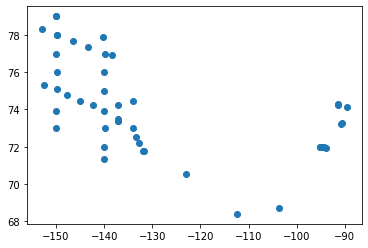

-- 2005 --


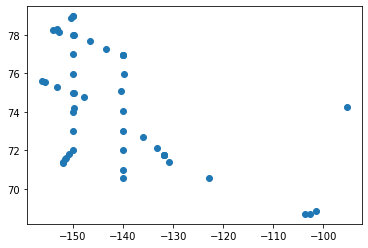

-- 2006 --


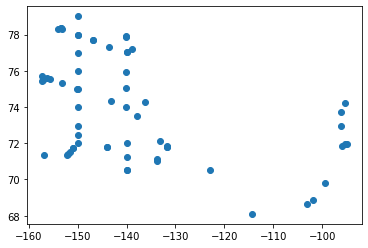

-- 2007 --


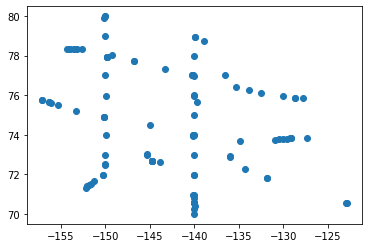

-- 2008 --


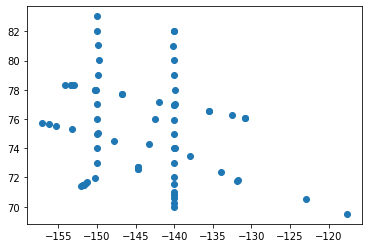

-- 2009 --


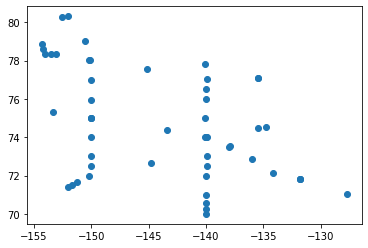

-- 2010 --


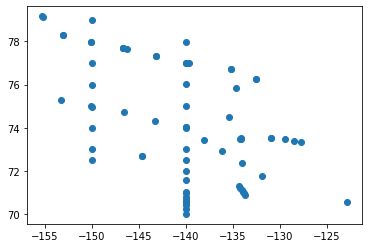

-- 2011 --


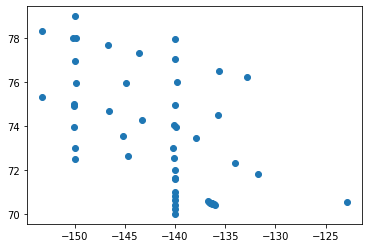

-- 2012 --


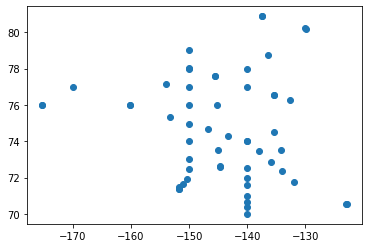

-- 2013 --


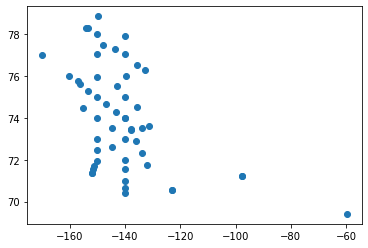

-- 2014 --


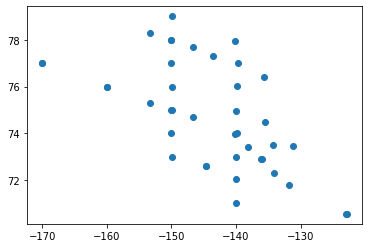

-- 2015 --


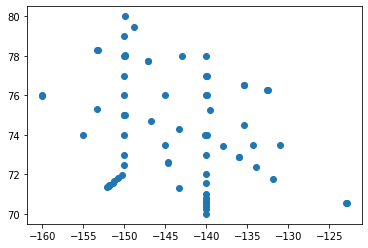

-- 2016 --


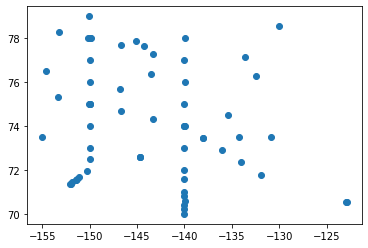

-- 2017 --


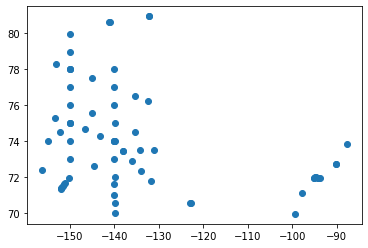

-- 2018 --


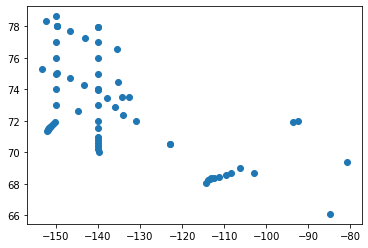

-- 2019 --


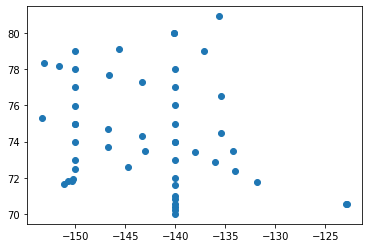

-- 2020 --


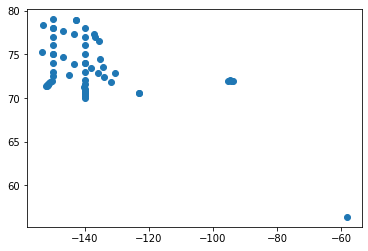

-- 2021 --


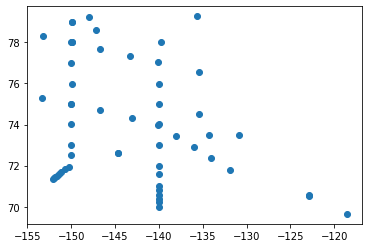

-- 2022 --


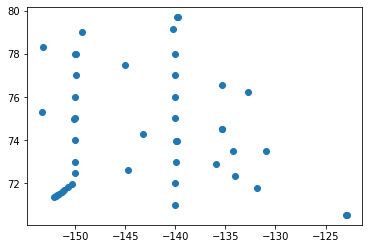

-- 2023 --


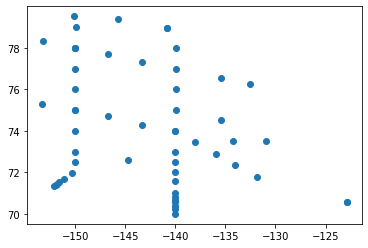

-- 2024 --


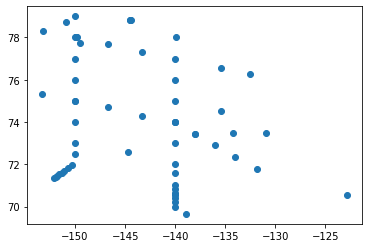

In [4]:
for year in range(2004,2025,1):
    print('--',year,'--')
    files = sorted(glob.glob('/data0/user/aprigent/BGEP/'+str(year)+'/*_T_S.nc'))

    ds_list = []
    for f in files:
        # print(f)
        ds = xr.open_dataset(f)
        # Expand along profile dimension
        ds = ds.expand_dims('profile')
        ds_list.append(ds)
    ds_all = xr.concat(ds_list, dim='profile')
    plt.scatter(ds_all.longitude,ds_all.latitude)
    plt.show()
    ds_all.to_netcdf('/data0/user/aprigent/BGEP/'+str(year)+'_ctd_TS.nc')